# Homework - Neural networks - Part B (55 points)
## Gradient descent for simple two and three layer models

by *Brenden Lake*

The first part of this assignment implements the gradient descent algorithm for a simple artificial neuron. The second part implements backpropagation for a simple network with one hidden unit. Remember that we strongly suggest you *TURN OFF* any autocompletion functionality (e.g., in VSCode and Cursor) so that you can learn and think as you do this assignment. For instance, in VSCode, edit `settings.json` (on mac search via command-P) such that quickSuggestions are off.
```
    "editor.quickSuggestions": {
        "other": "off",
        "comments": "off",
        "strings": "off"
    }
```
Alternatively, working with Jupyter notebooks in the terminal also removes this temptation. 

In the first part, the neuron will learn to compute logical OR. The neuron model and logical OR are shown below, for inputs $x_0$ and $x_1$ and target output $y$.

<img src="images/nn_OR.jpeg" style="width: 350px;"/>

This assignment requires some basic PyTorch knowledge. You can review your notes from lab and this [PyTorch tutorial](https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html). The "Introduction to PyTorch" section on the PyTorch website is also helpful.

In [1]:
# Import libraries
from __future__ import print_function
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch

In [2]:
# Fix random seeds so results are reproducible
torch.manual_seed(0)
np.random.seed(0)

Let's create `torch.tensor` objects for representing the data matrix `X` with targets `Y_or` (for the logical OR function). Each row of `X` is a different input pattern.

In [3]:
X_list = [[0.,0.], [0.,1.], [1.,0.], [1.,1.]]
X = torch.tensor(X_list)
Y_or = torch.tensor([0.,1.,1.,1.])
N = X.shape[0] # number of input patterns
print("Input tensor X:")
print('  has shape',X.shape)
print('  and contains',X)
print('Target tensor Y:')
print('  has shape',Y_or.shape)
print('  and contains',Y_or)

Input tensor X:
  has shape torch.Size([4, 2])
  and contains tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
Target tensor Y:
  has shape torch.Size([4])
  and contains tensor([0., 1., 1., 1.])


The artificial neuron operates as follows. Given an input vector $x$ (which is one row of input tensor $X$), the net input ($\textbf{net}$) to the neuron is computed as follows

$$ \textbf{net} = \sum_i x_i w_i + b,$$

for weights $w_i$ and bias $b$. The activation function $g(\textbf{net})$ is the logistic function

$$ g(\textbf{net}) = \frac{1}{1+e^{-\textbf{net}}},$$

which is used to compute the predicted output $\hat{y} = g(\textbf{net})$. Finally, the loss (squared error) for a particular pattern $x$ is defined as 

$$ E(w,b) = (\hat{y}-y)^2,$$

where the target output is $y$. **Your main task is to manually compute the partial derivatives of the loss $E$ with respect to the neuron parameters:**

$$\frac{\partial E(w,b)}{\partial w}, \frac{\partial E(w,b)}{\partial b}.$$

By manually, we mean to program the gradient computation directly, using the formulas discussed in class. This is in contrast to using PyTorch's `autograd` (Automatic differentiation) that computes the gradient automatically, as discussed in class, lab, and in the PyTorch tutorial (e.g., `loss.backward()`). First, let's write the activation function and the loss in PyTorch. 

In [4]:
def g_logistic(net):
    return 1. / (1.+torch.exp(-net))

def loss(yhat,y):
    return (yhat-y)**2

Next, we'll also write two functions for examining the internal operations of the neuron, and the gradients of its parameters.

In [5]:
def print_forward(x,yhat,y):
    # Examine network's prediction for input x
    print(' Input: ',end='')
    print(x.numpy())
    print(' Output: ' + str(round(yhat.item(),3)))
    print(' Target: ' + str(y.item()))

def print_grad(grad_w,grad_b):
    # Examine gradients
    print('  d_loss / d_w = ',end='')
    print(grad_w)
    print('  d_loss / d_b = ',end='')
    print(grad_b)

Now let's dive in and begin the implementation of stochastic gradient descent. We'll initialize our parameters $w$ and $b$ randomly, and proceed through a series of epochs of training. Each epoch involves visiting the four training patterns in random order, and updating the parameters after each presentation of an input pattern.



<div class="alert alert-success" role="alert">
<h3> Problem 1 (10 points) </h3>
<br>
In the code below, fill in code to manually compute the gradient in closed form.
    <ul>
        <li>See lecture slides for the equation for the gradient for the weights w.</li>
        <li>Derive (or reason) to get the equation for the gradient for bias b.</li>
    </ul>
</div>

<div class="alert alert-success" role="alert">
<h3> Problem 2 (5 points) </h3>
<br>
In the code below, fill in code for the weight and bias update rule for gradient descent.
</div>

After completing the code, run it to compare **your gradients** with the **ground-truth computed by PyTorch.** (There may be small differences that you shouldn't worry about, e.g. within 1e-6). Also, you can check the neuron's performance at the end of training.

Compute the gradient manually
 Input: [1. 0.]
 Output: 0.346
 Target: 1.0
  d_loss / d_w = [-0.29599196 -0.        ]
  d_loss / d_b = [-0.29599196]
Compute the gradient using PyTorch .backward()
  d_loss / d_w = [-0.29599196 -0.        ]
  d_loss / d_b = [-0.29599196]

Compute the gradient manually
 Input: [1. 1.]
 Output: 0.289
 Target: 1.0
  d_loss / d_w = [-0.29213744 -0.29213744]
  d_loss / d_b = [-0.29213744]
Compute the gradient using PyTorch .backward()
  d_loss / d_w = [-0.29213747 -0.29213747]
  d_loss / d_b = [-0.29213747]

Compute the gradient manually
 Input: [0. 1.]
 Output: 0.081
 Target: 1.0
  d_loss / d_w = [-0.         -0.13688438]
  d_loss / d_b = [-0.13688438]
Compute the gradient using PyTorch .backward()
  d_loss / d_w = [ 0.         -0.13688436]
  d_loss / d_b = [-0.13688436]

Compute the gradient manually
 Input: [0. 0.]
 Output: 0.105
 Target: 0.0
  d_loss / d_w = [0. 0.]
  d_loss / d_b = [0.01974555]
Compute the gradient using PyTorch .backward()
  d_loss / d_w

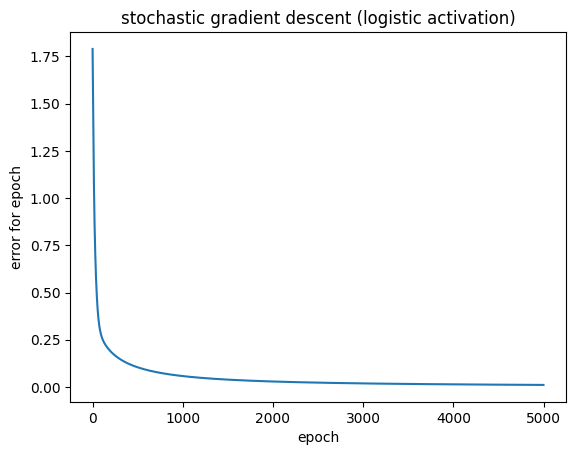

In [6]:
# Initialize parameters
#     Although you will implement gradient descent manually, let's set requires_grad=True
#     anyway so PyTorch will track the gradient too, and we can compare your gradient with PyTorch's.
w = torch.randn(2, requires_grad=True) # [size 2] tensor
b = torch.randn(1, requires_grad=True) # [size 1] tensor

alpha = 0.05 # learning rate
nepochs = 5000 # number of epochs

track_error = []
verbose = True
for e in range(nepochs): # for each epoch
    error_epoch = 0. # sum loss across the epoch
    perm = np.random.permutation(N)
    for p in perm: # visit data points in random order
        x_pat = X[p,:] # get one input pattern
        
        # compute output of neuron
        net = torch.dot(x_pat,w)+b
        yhat = g_logistic(net)
        
        # compute loss
        y = Y_or[p]
        myloss = loss(yhat,y)
        error_epoch += myloss.item()
        
        # Compute the gradient manually
        if verbose:
            print('Compute the gradient manually')
            print_forward(x_pat,yhat,y)
        with torch.no_grad():
            # TODO : YOUR GRADIENT CODE GOES HERE
            #  two lines of the form
            #    w_grad = ...    ([size 2] PyTorch tensor)
            #    b_grad = ...    ([size 1] PyTorch tensor)
            #  make sure to enclose your code in the "with torch.no_grad()" wrapper,
            #   otherwise PyTorch will try to track the "gradient" of the gradient computation, which we don't want.         
            w_grad = 2*(yhat - y)*yhat*(1 - yhat) * x_pat # dE/dyhat * dyhat/dnet * dnet/dw
            b_grad = 2*(yhat - y)*yhat*(1 - yhat)         # dE/dyhat * dyhat/dnet * dnet/db (=1)
        if verbose: print_grad(w_grad.numpy(),b_grad.numpy())

        # Compute the gradient with PyTorch and compare with manual values
        if verbose: print('Compute the gradient using PyTorch .backward()')
        myloss.backward()
        if verbose:
            print_grad(w.grad.numpy(),b.grad.numpy())
            print("")
        w.grad.zero_() # clear PyTorch's gradient
        b.grad.zero_()
        
        # Parameter update with gradient descent
        with torch.no_grad():
            # TODO : YOUR PARAMETER UPDATE CODE GOES HERE
            #  two lines of the form:
            #    w -=   ....
            #    b -=   ....
            w -= alpha * w_grad
            b -= alpha * b_grad
            
    if verbose==True: verbose=False
    track_error.append(error_epoch)
    if e % 50 == 0:
        print("epoch " + str(e) + "; error=" +str(round(error_epoch,3)))

# print a final pass through patterns
for p in range(X.shape[0]):
    x_pat = X[p]
    net = torch.dot(x_pat,w)+b
    yhat = g_logistic(net)
    y = Y_or[p]
    print("Final result:")
    print_forward(x_pat,yhat,y)
    print("")
    
# track output of gradient descent
plt.figure()
plt.clf()
plt.plot(track_error)
plt.title('stochastic gradient descent (logistic activation)')
plt.ylabel('error for epoch')
plt.xlabel('epoch')
plt.show()

Now let's change the activation function to "linear" (identity function) from the "logistic" function, such that $g(\textbf{net}) = \textbf{net}$. With a linear rather than logistic activation, the output will no longer be constrained between 0 and 1. The artificial neuron will still try to solve the problem with 0/1 targets. Here is the simple implementation of $g(\cdot)$:

In [7]:
def g_linear(x):
    return x

<div class="alert alert-success" role="alert">
<h3> Problem 3 (5 points) </h3>
<br>
Just as before, fill in the missing code fragments for implementing gradient descent. This time we are using the linear activation function. Be sure to change your gradient calculation to reflect the new activation function.
</div>

Compute the gradient manually
 Input: [1. 1.]
 Output: -1.915
 Target: 1.0
  d_loss / d_w = [-5.8293734 -5.8293734]
  d_loss / d_b = [-5.8293734]
Compute the gradient using PyTorch .backward()
  d_loss / d_w = [-5.8293734 -5.8293734]
  d_loss / d_b = [-5.8293734]

Compute the gradient manually
 Input: [0. 0.]
 Output: -1.107
 Target: 0.0
  d_loss / d_w = [-0. -0.]
  d_loss / d_b = [-2.2142534]
Compute the gradient using PyTorch .backward()
  d_loss / d_w = [0. 0.]
  d_loss / d_b = [-2.2142534]

Compute the gradient manually
 Input: [0. 1.]
 Output: -1.789
 Target: 1.0
  d_loss / d_w = [-0.        -5.5789356]
  d_loss / d_b = [-5.5789356]
Compute the gradient using PyTorch .backward()
  d_loss / d_w = [ 0.        -5.5789356]
  d_loss / d_b = [-5.5789356]

Compute the gradient manually
 Input: [1. 0.]
 Output: 0.142
 Target: 1.0
  d_loss / d_w = [-1.7151347 -0.       ]
  d_loss / d_b = [-1.7151347]
Compute the gradient using PyTorch .backward()
  d_loss / d_w = [-1.7151347  0.       ]
  

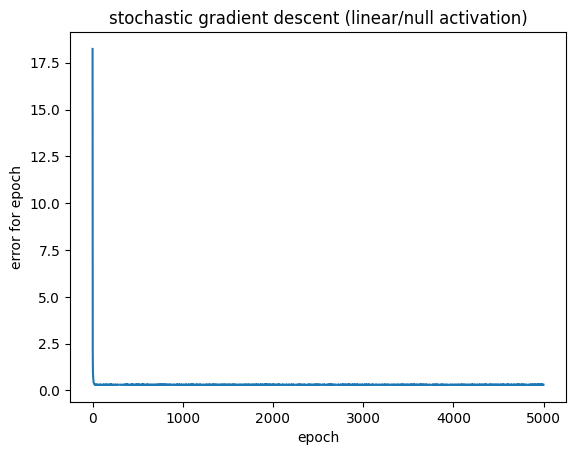

In [8]:
# Initialize parameters
#     Although you will implement gradient descent manually, let's set requires_grad=True
#     anyway so PyTorch will track the gradient too, and we can compare your gradient with PyTorch's.
w = torch.randn(2, requires_grad=True) # [size 2] tensor
b = torch.randn(1, requires_grad=True) # [size 1] tensor

alpha = 0.05 # learning rate
nepochs = 5000 # number of epochs

track_error = []
verbose = True
for e in range(nepochs): # for each epoch
    error_epoch = 0. # sum loss across the epoch
    perm = np.random.permutation(N)
    for p in perm: # visit data points in random order
        x_pat = X[p,:] # get one input pattern
        
        # compute output of neuron
        net = torch.dot(x_pat,w)+b
        yhat = g_linear(net)
        
        # compute loss
        y = Y_or[p]
        myloss = loss(yhat,y)
        error_epoch += myloss.item()
        
        # Compute the gradient manually
        if verbose:
            print('Compute the gradient manually')
            print_forward(x_pat,yhat,y)
        with torch.no_grad():
            # TODO : YOUR GRADIENT CODE GOES HERE
            #  two lines of the form
            #    w_grad = ...    ([size 2] PyTorch tensor)
            #    b_grad = ...    ([size 1] PyTorch tensor)
            #  make sure to enclose your code in the "with torch.no_grad()" wrapper,
            #   otherwise PyTorch will try to track the "gradient" of the gradient computation, which we don't want.         
            w_grad = 2*(yhat - y) * x_pat # dE/dyhat * dyhat/dnet (=1 for linear) * dnet/dw
            b_grad = 2*(yhat - y)         # dE/dyhat * dyhat/dnet (=1 for linear) * dnet/db (=1)
        if verbose: print_grad(w_grad.numpy(),b_grad.numpy())

        # Compute the gradient with PyTorch and compare with manual values
        if verbose: print('Compute the gradient using PyTorch .backward()')
        myloss.backward()
        if verbose:
            print_grad(w.grad.numpy(),b.grad.numpy())
            print("")
        w.grad.zero_() # clear PyTorch's gradient
        b.grad.zero_()
        
        # Parameter update with gradient descent
        with torch.no_grad():
            # TODO : YOUR PARAMETER UPDATE CODE GOES HERE
            #  two lines of the form:
            #    w -=   ....
            #    b -=   ....
            w -= alpha * w_grad
            b -= alpha * b_grad
            
    if verbose==True: verbose=False
    track_error.append(error_epoch)
    if e % 50 == 0:
        print("epoch " + str(e) + "; error=" +str(round(error_epoch,3)))

# print a final pass through patterns
for p in range(X.shape[0]):
    x_pat = X[p]
    net = torch.dot(x_pat,w)+b
    yhat = g_linear(net)
    y = Y_or[p]
    print("Final result:")
    print_forward(x_pat,yhat,y)
    print("")
    
# track output of gradient descent
plt.figure()
plt.clf()
plt.plot(track_error)
plt.title('stochastic gradient descent (linear/null activation)')
plt.ylabel('error for epoch')
plt.xlabel('epoch')
plt.show()

In [9]:
# Learned parameters for the linear neuron
print('w =',w.data.numpy(),' b =',b.item())

w = [0.48346823 0.4808231 ]  b = 0.2670857012271881


<div class="alert alert-success" role="alert">
<h3> Problem 4 (10 points) </h3>
<br>
You'll see above that the artificial neuron, with the simple linear (identity) activation, does worse on the OR problem. Examine the learned weights and bias, and explain why the network does not arrive at a perfect solution.
</div>

**Answer:** The learned parameters are $w_0 \approx 0.48$, $w_1 \approx 0.48$, $b \approx 0.27$, giving outputs of about 0.27, 0.75, 0.75, and 1.23 for the four patterns (targets 0, 1, 1, 1). With a linear activation, the output is just $w_0 x_0 + w_1 x_1 + b$, so each active input adds a fixed amount and the effects simply sum; there is no squashing function to "saturate" at 1. OR needs the output to be the same (1) whether one or both inputs are on, but a linear unit cannot do this: if the weights were large enough ($\approx 1$) to bring [0,1] and [1,0] up to 1, then [1,1] would output $\approx 2$, and the bias needed for [0,0] to be 0 would also be in conflict. Since no linear function fits all four targets exactly, gradient descent instead finds the compromise that minimizes the total squared error, which is $w_0 = w_1 = 0.5$, $b = 0.25$ (outputs 0.25, 0.75, 0.75, 1.25, each off by 0.25). Our learned values hover around this least-squares solution because stochastic updates keep nudging them. The logistic neuron avoids this problem because its output flattens out near 1, so a large net input from one or two active inputs produces nearly the same output.

In the next part, we have a simple multi-layer network with two input neurons, one hidden neuron, and one output neuron. Both the hidden and output unit should use the logistic activation function. We will learn to compute logical XOR. The network and logical XOR are shown below, for inputs $x_0$ and $x_1$ and target output $y$.

<img src="images/nn_XOR.jpeg" style="width: 500px;"/>

<div class="alert alert-success" role="alert">
<h3> Problem 5 (15 points) </h3>
<br>
You will implement backpropagation for this simple network. In the code below, you have several parts to fill in. First, define the forward pass to compute the output `yhat` from the input `x`. Second, fill in code to manually compute the gradients for all five weights w and two biases b in closed form. Third, fill in the code for updating the biases and weights.
</div>

After completing the code, run it to compare **your gradients** with the **ground-truth computed by PyTorch.** (There may be small differences that you shouldn't worry about, e.g. within 1e-6). Also, you can check the network's performance at the end of training.

Compute the gradient manually
 Input: [1. 0.]
 Output: 0.124
 Target: 1.0
 Grad for w_34 and b_0
  d_loss / d_w = [0.02602027 0.        ]
  d_loss / d_b = [0.02602027]
 Grad for w_012 and b_1
  d_loss / d_w = [-0.18982297 -0.         -0.12192427]
  d_loss / d_b = [-0.18982297]

Compute the gradient using PyTorch .backward()
 Grad for w_34 and b_0
  d_loss / d_w = [0.02602027 0.        ]
  d_loss / d_b = [0.02602027]
 Grad for w_012 and b_1
  d_loss / d_w = [-0.18982297  0.         -0.12192427]
  d_loss / d_b = [-0.18982297]

Compute the gradient manually
 Input: [0. 0.]
 Output: 0.237
 Target: 0.0
 Grad for w_34 and b_0
  d_loss / d_w = [-0. -0.]
  d_loss / d_b = [-0.01255374]
 Grad for w_012 and b_1
  d_loss / d_w = [0.         0.         0.04672741]
  d_loss / d_b = [0.08572872]

Compute the gradient using PyTorch .backward()
 Grad for w_34 and b_0
  d_loss / d_w = [0. 0.]
  d_loss / d_b = [-0.01255374]
 Grad for w_012 and b_1
  d_loss / d_w = [0.         0.         0.04672741]
  d_l

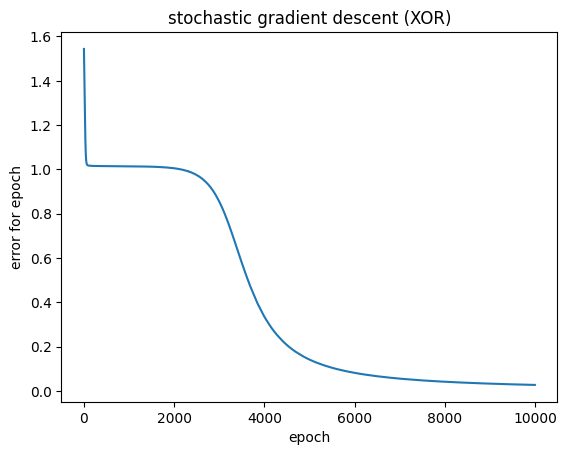

In [10]:
# Same input tensor X and new labels y for xor
Y_xor = torch.tensor([0.,1.,1.,0.])
N = X.shape[0] # number of input patterns

# Initialize parameters
#     Although you will implement gradient descent manually, let's set requires_grad=True
#     anyway so PyTorch will track the gradient too, and we can compare your gradient with PyTorch's.
w_34 = torch.randn(2,requires_grad=True) # [size 2] tensor representing [w_3,w_4]
w_012 = torch.randn(3,requires_grad=True) # [size 3] tensor representing [w_0,w_1,w_2]
b_0 = torch.randn(1,requires_grad=True) # [size 1] tensor
b_1 = torch.randn(1,requires_grad=True) # [size 1] tensor

alpha = 0.05 # learning rate
nepochs = 10000 # number of epochs

track_error = []
verbose = True
for e in range(nepochs): # for each epoch
    error_epoch = 0. # sum loss across the epoch
    perm = np.random.permutation(N)
    for p in perm: # visit data points in random order
        x_pat = X[p,:] # input pattern
        
        # Compute the output of hidden neuron h
        # e.g., two lines like the following
        #  net_h = ...
        #  h = ...
        # TODO : YOUR CODE GOES HERE
        net_h = torch.dot(x_pat,w_34) + b_0
        h = g_logistic(net_h)
        
        # Compute the output of neuron yhat
        # e.g., two lines like the following
        #  net_y = ...
        #  yhat = ...
        # TODO : YOUR CODE GOES HERE
        net_y = torch.dot(x_pat,w_012[:2]) + w_012[2]*h + b_1
        yhat = g_logistic(net_y)
        
        # compute loss
        y = Y_xor[p]
        myloss = loss(yhat,y)
        error_epoch += myloss.item()
        
        # print output if this is the last epoch
        if (e == nepochs-1):
            print("Final result:")
            print_forward(x_pat,yhat,y)
            print("")

        # Compute the gradient manually
        if verbose:
            print('Compute the gradient manually')
            print_forward(x_pat,yhat,y)
        with torch.no_grad():
            # TODO : YOUR GRADIENT CODE GOES HERE
            #  should include at least these 4 lines (helper lines may be useful)
            #    w_34_grad = ...  
            #    b_0_grad = ...
            #    w_012_grad = ...
            #    b_1_grad = ...
            #  make sure to enclose your code in the "with torch.no_grad()" wrapper,
            #   otherwise PyTorch will try to track the "gradient" of the gradient computation, which we don't want.
            delta_y = 2*(yhat - y)*yhat*(1 - yhat) # error signal at output
            w_012_grad = delta_y * torch.cat((x_pat,h)) # inputs to output unit: [x0,x1,h]
            b_1_grad = delta_y
            delta_h = delta_y * w_012[2] * h*(1 - h) # backpropagate through w_2
            w_34_grad = delta_h * x_pat
            b_0_grad = delta_h
        if verbose:
            print(" Grad for w_34 and b_0")
            print_grad(w_34_grad.numpy(),b_0_grad.numpy())
            print(" Grad for w_012 and b_1")
            print_grad(w_012_grad.numpy(),b_1_grad.numpy())
            print("")

        # Compute the gradient with PyTorch and compare with manual values
        if verbose: print('Compute the gradient using PyTorch .backward()')
        myloss.backward()
        if verbose:
            print(" Grad for w_34 and b_0")
            print_grad(w_34.grad.numpy(),b_0.grad.numpy())
            print(" Grad for w_012 and b_1")
            print_grad(w_012.grad.numpy(),b_1.grad.numpy())
            print("")
        w_34.grad.zero_() # clear PyTorch's gradient
        b_0.grad.zero_()
        w_012.grad.zero_()
        b_1.grad.zero_()
        
        # Parameter update with gradient descent
        with torch.no_grad():
            # TODO : YOUR PARAMETER UPDATE CODE GOES HERE
            # Four lines of the form
            # w_34 -= ...
            # b_0 -= ...
            # w_012 -= ...
            # b_1 -= ...
            w_34 -= alpha * w_34_grad
            b_0 -= alpha * b_0_grad
            w_012 -= alpha * w_012_grad
            b_1 -= alpha * b_1_grad
            
    if verbose==True: verbose=False
    track_error.append(error_epoch)
    if e % 50 == 0:
        print("epoch " + str(e) + "; error=" +str(round(error_epoch,3)))

# track output of gradient descent
plt.figure()
plt.clf()
plt.plot(track_error)
plt.title('stochastic gradient descent (XOR)')
plt.ylabel('error for epoch')
plt.xlabel('epoch')
plt.show()

<div class="alert alert-success" role="alert">
<h3> Problem 6 (10 points) </h3>
<br>
After running your XOR network, print the values of the learned weights and biases. Your job now is to describe the solution that the network has learned. How does it work? Walk through each input pattern to describe how the network computes the right answer (if it does). See discussion in lecture for an example.
</div>

In [11]:
# Learned XOR parameters, and what each unit does for each input pattern
print('w_34 =',w_34.data.numpy(),' b_0 =',b_0.item())
print('w_012 =',w_012.data.numpy(),' b_1 =',b_1.item())
with torch.no_grad():
    for p in range(N):
        x_pat = X[p]
        net_h = torch.dot(x_pat,w_34) + b_0
        h = g_logistic(net_h)
        net_y = torch.dot(x_pat,w_012[:2]) + w_012[2]*h + b_1
        yhat = g_logistic(net_y)
        print(f'x={x_pat.numpy()}  net_h={net_h.item():7.2f}  h={h.item():.3f}  net_y={net_y.item():7.2f}  yhat={yhat.item():.3f}  target={Y_xor[p].item():.0f}')

w_34 = [6.6760035 6.677774 ]  b_0 = -2.728466749191284
w_012 = [-4.90621  -4.906645 10.74449 ]  b_1 = -3.2046456336975098
x=[0. 0.]  net_h=  -2.73  h=0.061  net_y=  -2.55  yhat=0.073  target=0
x=[0. 1.]  net_h=   3.95  h=0.981  net_y=   2.43  yhat=0.919  target=1
x=[1. 0.]  net_h=   3.95  h=0.981  net_y=   2.43  yhat=0.919  target=1
x=[1. 1.]  net_h=  10.63  h=1.000  net_y=  -2.27  yhat=0.093  target=0


**Answer:** Learned weights: hidden unit $w_3 \approx w_4 \approx 6.7$, $b_0 \approx -2.7$; output unit $w_0 \approx w_1 \approx -4.9$, $w_2 \approx 10.7$, $b_1 \approx -3.2$.

The hidden unit works like an **OR** meaning it turns on if at least one input is on. The output unit gets a big boost from the hidden unit but is pushed down by each input directly. One input on isn't enough to cancel the boost, but two inputs on is. So the network computes "OR, but not both", which is XOR.

- **[0,0]:** Hidden unit is off, so the output only gets its negative bias. Output $\approx 0.07$ (target 0).
- **[0,1] and [1,0]:** Hidden unit turns on and boosts the output; one input pushes it down a little. Output $\approx 0.92$ (target 1).
- **[1,1]:** Hidden unit is on, but both inputs push the output down, cancelling the boost. Output $\approx 0.09$ (target 0).

So the network gets all four patterns right.